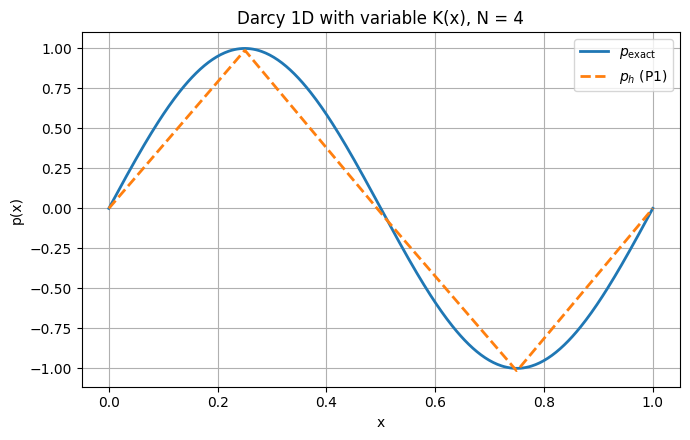

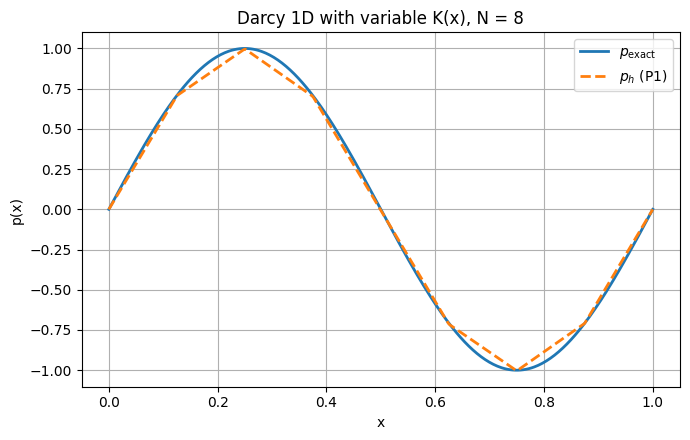

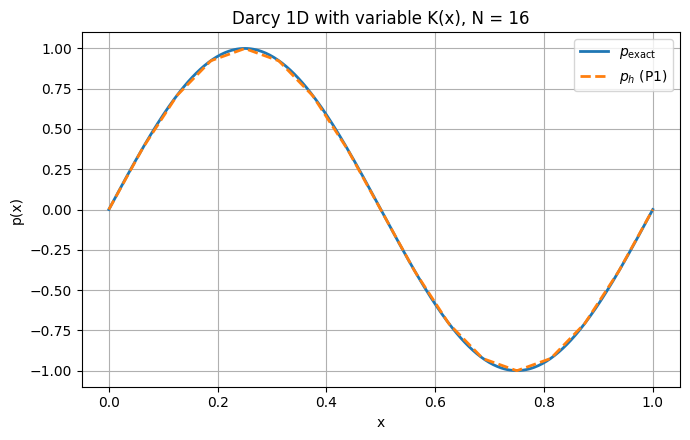

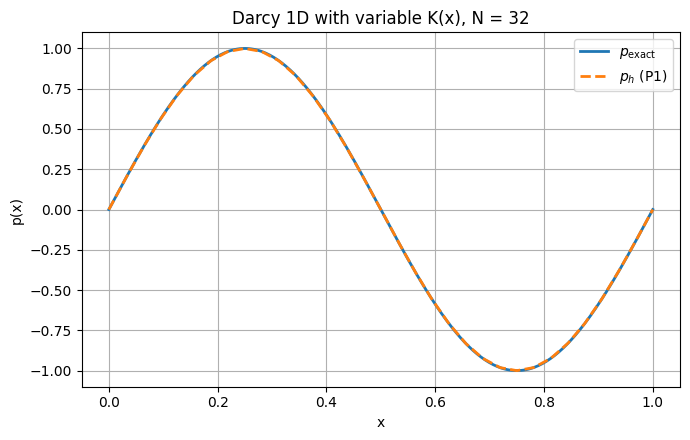

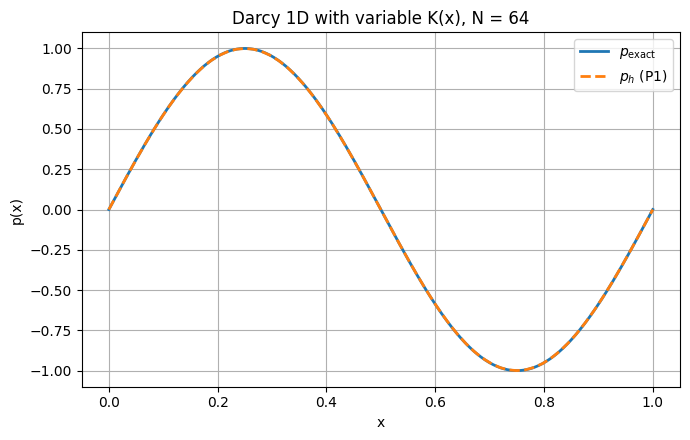

       N            h         ||e||_L2     rate(L2)           |e|_H1     rate(H1)
----------------------------------------------------------------------------------
       4 2.500000e-01   1.50463757e-01          ---   1.93460567e+00          ---
       8 1.250000e-01   3.92085750e-02     1.940175   9.97138754e-01     0.956173
      16 6.250000e-02   9.90313092e-03     1.985213   5.02379059e-01     0.989018
      32 3.125000e-02   2.48211910e-03     1.996312   2.51668266e-01     0.997253
      64 1.562500e-02   6.20926189e-04     1.999079   1.25894054e-01     0.999313


In [1]:
from mpi4py import MPI
from petsc4py import PETSc
import numpy as np
from math import log
import matplotlib.pyplot as plt
import math

from dolfinx import fem, mesh, geometry
from dolfinx.fem.petsc import LinearProblem
import ufl


def exact_p_array(x):
    # x has shape (gdim, num_points)
    return np.sin(2 * np.pi * x[0])


def solve_darcy_1d(ncells: int):
    """
    Solve
        -(K(x) p')' = f  on (0,1),
    with
        K(x) = 2 + x^2,
        p_exact(x) = sin(2*pi*x),
        f(x) = 4*pi^2*(2 + x^2)*sin(2*pi*x) - 4*pi*x*cos(2*pi*x).
    """
    comm = MPI.COMM_WORLD

    # Mesh
    domain = mesh.create_interval(comm, ncells, [0.0, 1.0])

    # P2 space
    V = fem.functionspace(domain, ("Lagrange", 1))

    # Trial and test functions
    p = ufl.TrialFunction(V)
    v = ufl.TestFunction(V)

    x = ufl.SpatialCoordinate(domain)

    # Variable permeability
    K = 2.0 + x[0] ** 2

    # Exact forcing for p_exact = sin(2*pi*x)
    f = (
        4 * math.pi**2 * (2.0 + x[0] ** 2) * ufl.sin(2 * math.pi * x[0])
        - 4 * math.pi * x[0] * ufl.cos(2 * math.pi * x[0])
    )

    # Weak form: ∫ K p' v' dx = ∫ f v dx
    a = K * ufl.inner(ufl.grad(p), ufl.grad(v)) * ufl.dx
    L = f * v * ufl.dx

    # Boundary markers
    def left_boundary(x):
        return np.isclose(x[0], 0.0)

    def right_boundary(x):
        return np.isclose(x[0], 1.0)

    left_dofs = fem.locate_dofs_geometrical(V, left_boundary)
    right_dofs = fem.locate_dofs_geometrical(V, right_boundary)

    # p_exact(0)=0 and p_exact(1)=0
    p_left = fem.Constant(domain, PETSc.ScalarType(0.0))
    p_right = fem.Constant(domain, PETSc.ScalarType(0.0))

    bc_left = fem.dirichletbc(p_left, left_dofs, V)
    bc_right = fem.dirichletbc(p_right, right_dofs, V)
    bcs = [bc_left, bc_right]

    # Solve
    problem = LinearProblem(
        a,
        L,
        bcs=bcs,
        petsc_options_prefix=f"darcy1d_{ncells}_",
        petsc_options={
            "ksp_type": "preonly",
            "pc_type": "lu",
        },
    )

    ph = problem.solve()
    ph.name = "p_h"

    # Higher-order space for error computation
    W = fem.functionspace(domain, ("Lagrange", 4))

    p_exact_h = fem.Function(W)
    p_exact_h.interpolate(exact_p_array)

    ph_high = fem.Function(W)
    ph_high.interpolate(ph)

    # L2 error
    e_L2_form = fem.form((ph_high - p_exact_h) ** 2 * ufl.dx)
    e_L2 = np.sqrt(comm.allreduce(fem.assemble_scalar(e_L2_form), op=MPI.SUM))

    # H1 seminorm error
    e_H1_form = fem.form(
        ufl.inner(ufl.grad(ph_high - p_exact_h), ufl.grad(ph_high - p_exact_h)) * ufl.dx
    )
    e_H1 = np.sqrt(comm.allreduce(fem.assemble_scalar(e_H1_form), op=MPI.SUM))

    h = 1.0 / ncells
    return domain, ph, h, e_L2, e_H1


def convergence_rate(errors, hs):
    rates = [None]
    for i in range(1, len(errors)):
        r = log(errors[i - 1] / errors[i]) / log(hs[i - 1] / hs[i])
        rates.append(r)
    return rates


def plot_solution(domain, ph, ncells):
    """
    Plot p_h and p_exact on a fine set of points in [0,1].
    """
    comm = domain.comm
    rank = comm.rank

    # Fine plotting points
    x_plot = np.linspace(0.0, 1.0, 400, dtype=np.float64)
    points = np.zeros((len(x_plot), 3), dtype=np.float64)
    points[:, 0] = x_plot

    # Locate cells containing the points
    tree = geometry.bb_tree(domain, domain.topology.dim)
    cell_candidates = geometry.compute_collisions_points(tree, points)
    colliding_cells = geometry.compute_colliding_cells(domain, cell_candidates, points)

    points_on_proc = []
    cells = []
    x_local = []

    for i, point in enumerate(points):
        cell_list = colliding_cells.links(i)
        if len(cell_list) > 0:
            points_on_proc.append(point)
            cells.append(cell_list[0])
            x_local.append(x_plot[i])

    points_on_proc = np.array(points_on_proc, dtype=np.float64)
    x_local = np.array(x_local, dtype=np.float64)

    if len(points_on_proc) > 0:
        ph_vals_local = ph.eval(points_on_proc, cells).flatten()
        # pexact_vals_local = x_local * (1.0 - x_local)
        pexact_vals_local = np.sin(2*math.pi*x_local)
    else:
        ph_vals_local = np.array([], dtype=np.float64)
        pexact_vals_local = np.array([], dtype=np.float64)

    gathered_x = comm.gather(x_local, root=0)
    gathered_ph = comm.gather(ph_vals_local, root=0)
    gathered_pe = comm.gather(pexact_vals_local, root=0)

    if rank == 0:
        x_all = np.concatenate(gathered_x)
        ph_all = np.concatenate(gathered_ph)
        pe_all = np.concatenate(gathered_pe)

        idx = np.argsort(x_all)
        x_all = x_all[idx]
        ph_all = ph_all[idx]
        pe_all = pe_all[idx]

        plt.figure(figsize=(7, 4.5))
        plt.plot(x_all, pe_all, label=r"$p_{\mathrm{exact}}$", linewidth=2)
        plt.plot(x_all, ph_all, "--", label=r"$p_h$ (P1)", linewidth=2)
        plt.xlabel("x")
        plt.ylabel("p(x)")
        plt.title(f"Darcy 1D with variable K(x), N = {ncells}")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()


if __name__ == "__main__":
    mesh_sizes = [4, 8, 16, 32, 64]

    hs = []
    L2_errors = []
    H1_errors = []

    for n in mesh_sizes:
        domain, ph, h, eL2, eH1 = solve_darcy_1d(n)

        hs.append(h)
        L2_errors.append(eL2)
        H1_errors.append(eH1)

        # Plot p_h and p_exact for each mesh
        plot_solution(domain, ph, n)

    L2_rates = convergence_rate(L2_errors, hs)
    H1_rates = convergence_rate(H1_errors, hs)

    if MPI.COMM_WORLD.rank == 0:
        print(f"{'N':>8} {'h':>12} {'||e||_L2':>16} {'rate(L2)':>12} {'|e|_H1':>16} {'rate(H1)':>12}")
        print("-" * 82)
        for i, n in enumerate(mesh_sizes):
            rL2 = "---" if L2_rates[i] is None else f"{L2_rates[i]:.6f}"
            rH1 = "---" if H1_rates[i] is None else f"{H1_rates[i]:.6f}"
            print(
                f"{n:8d} {hs[i]:12.6e} {L2_errors[i]:16.8e} {rL2:>12} "
                f"{H1_errors[i]:16.8e} {rH1:>12}"
            )

Epoch     0 | total_loss = 4.253560e+03 | pde_residual = 4.253560e+03 | ||r_θ|| = 0.000000e+00
Epoch   500 | total_loss = 1.229918e+03 | pde_residual = 1.229549e+03 | ||r_θ|| = 6.074128e+00
Epoch  1000 | total_loss = 8.005975e+01 | pde_residual = 7.903907e+01 | ||r_θ|| = 1.010288e+01
Epoch  1500 | total_loss = 2.061336e+01 | pde_residual = 1.946307e+01 | ||r_θ|| = 1.072515e+01
Epoch  2000 | total_loss = 1.066387e+01 | pde_residual = 9.515747e+00 | ||r_θ|| = 1.071505e+01
Epoch  2500 | total_loss = 6.378541e+00 | pde_residual = 5.254354e+00 | ||r_θ|| = 1.060277e+01
Epoch  3000 | total_loss = 4.551408e+00 | pde_residual = 3.443482e+00 | ||r_θ|| = 1.052581e+01
Epoch  3500 | total_loss = 3.618137e+00 | pde_residual = 2.519500e+00 | ||r_θ|| = 1.048159e+01
Epoch  4000 | total_loss = 2.985474e+00 | pde_residual = 1.891524e+00 | ||r_θ|| = 1.045920e+01
Epoch  4500 | total_loss = 2.523342e+00 | pde_residual = 1.431559e+00 | ||r_θ|| = 1.044884e+01
Epoch  4999 | total_loss = 2.207475e+00 | pde_resi

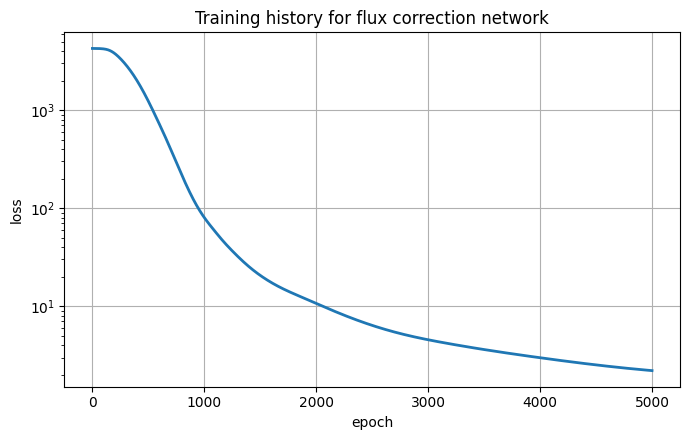

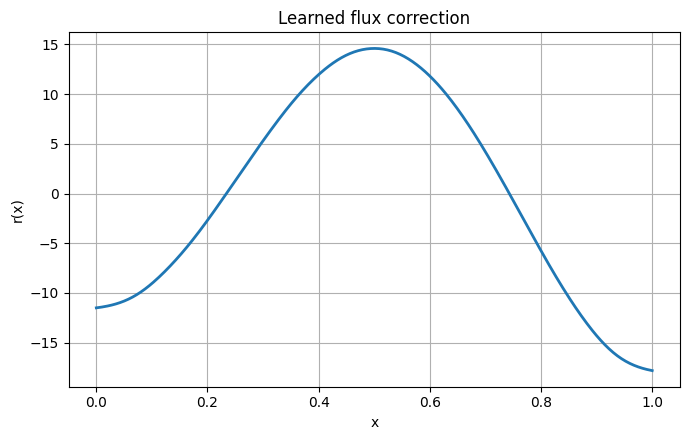

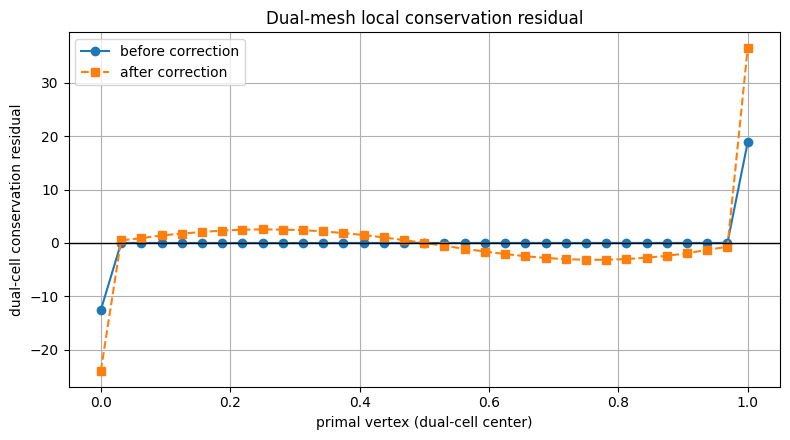

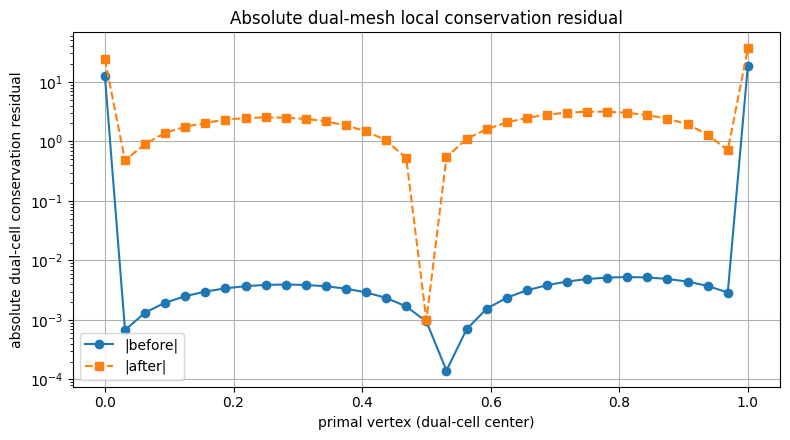

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim


# ------------------------------------------------------------
# Utilities for cellwise data from the FE solution
# ------------------------------------------------------------
import numpy as np
import basix


import numpy as np
import basix


def extract_cell_data_1d(domain, ph):
    """
    For each local cell on a 1D interval mesh, extract:
      - x_left, x_right, x_center
      - p_h'(x) at left, center, right
      - p_h''(x) at left, center, right

    Gather everything on rank 0.

    Returns
    -------
    x_left, x_right, x_center,
    dpdx_left, dpdx_center, dpdx_right,
    d2pdx2_left, d2pdx2_center, d2pdx2_right

    On rank 0: numpy arrays sorted by x_center
    On other ranks: None, ..., None
    """
    comm = domain.comm
    V = ph.function_space
    tdim = domain.topology.dim

    if tdim != 1:
        raise ValueError("This routine is written for 1D interval meshes only.")

    domain.topology.create_connectivity(tdim, 0)
    c_to_v = domain.topology.connectivity(tdim, 0)

    u = ph.x.array
    num_cells_local = domain.topology.index_map(tdim).size_local

    x_left_local = np.zeros(num_cells_local, dtype=np.float64)
    x_right_local = np.zeros(num_cells_local, dtype=np.float64)
    x_center_local = np.zeros(num_cells_local, dtype=np.float64)

    dpdx_left_local = np.zeros(num_cells_local, dtype=np.float64)
    dpdx_center_local = np.zeros(num_cells_local, dtype=np.float64)
    dpdx_right_local = np.zeros(num_cells_local, dtype=np.float64)

    d2pdx2_left_local = np.zeros(num_cells_local, dtype=np.float64)
    d2pdx2_center_local = np.zeros(num_cells_local, dtype=np.float64)
    d2pdx2_right_local = np.zeros(num_cells_local, dtype=np.float64)

    basix_el = V.element.basix_element

    # Reference points on [0,1]: left, center, right
    ref_pts = np.array([[0.0], [0.5], [1.0]], dtype=np.float64)

    # Tabulate up to second derivatives
    # tab shape: (nderivs, npoints, ndofs, value_size)
    tab = basix_el.tabulate(2, ref_pts)

    dphi_dxi = tab[1, :, :, 0]      # shape (3, ndofs)
    d2phi_dxi2 = tab[2, :, :, 0]    # shape (3, ndofs)

    for cell in range(num_cells_local):
        cell_dofs = V.dofmap.cell_dofs(cell)
        u_cell = u[cell_dofs]

        verts = c_to_v.links(cell)
        xv = domain.geometry.x[verts, 0]

        x0 = np.min(xv)
        x1 = np.max(xv)
        h = x1 - x0

        if h <= 0:
            raise ValueError(f"Non-positive cell length detected on cell {cell}.")

        # Chain rule from reference interval [0,1] to physical cell [x0,x1]
        # x = x0 + h * xi
        # d/dx = (1/h) d/dxi
        # d2/dx2 = (1/h^2) d2/dxi2
        dpdx_left = (dphi_dxi[0] @ u_cell) / h
        dpdx_center = (dphi_dxi[1] @ u_cell) / h
        dpdx_right = (dphi_dxi[2] @ u_cell) / h

        d2pdx2_left = (d2phi_dxi2[0] @ u_cell) / (h**2)
        d2pdx2_center = (d2phi_dxi2[1] @ u_cell) / (h**2)
        d2pdx2_right = (d2phi_dxi2[2] @ u_cell) / (h**2)

        x_left_local[cell] = x0
        x_right_local[cell] = x1
        x_center_local[cell] = 0.5 * (x0 + x1)

        dpdx_left_local[cell] = dpdx_left
        dpdx_center_local[cell] = dpdx_center
        dpdx_right_local[cell] = dpdx_right

        d2pdx2_left_local[cell] = d2pdx2_left
        d2pdx2_center_local[cell] = d2pdx2_center
        d2pdx2_right_local[cell] = d2pdx2_right

    gathered_left = comm.gather(x_left_local, root=0)
    gathered_right = comm.gather(x_right_local, root=0)
    gathered_center = comm.gather(x_center_local, root=0)

    gathered_dpdx_left = comm.gather(dpdx_left_local, root=0)
    gathered_dpdx_center = comm.gather(dpdx_center_local, root=0)
    gathered_dpdx_right = comm.gather(dpdx_right_local, root=0)

    gathered_d2pdx2_left = comm.gather(d2pdx2_left_local, root=0)
    gathered_d2pdx2_center = comm.gather(d2pdx2_center_local, root=0)
    gathered_d2pdx2_right = comm.gather(d2pdx2_right_local, root=0)

    if comm.rank == 0:
        x_left = np.concatenate(gathered_left)
        x_right = np.concatenate(gathered_right)
        x_center = np.concatenate(gathered_center)

        dpdx_left = np.concatenate(gathered_dpdx_left)
        dpdx_center = np.concatenate(gathered_dpdx_center)
        dpdx_right = np.concatenate(gathered_dpdx_right)

        d2pdx2_left = np.concatenate(gathered_d2pdx2_left)
        d2pdx2_center = np.concatenate(gathered_d2pdx2_center)
        d2pdx2_right = np.concatenate(gathered_d2pdx2_right)

        idx = np.argsort(x_center)

        return (
            x_left[idx],
            x_right[idx],
            x_center[idx],
            dpdx_left[idx],
            dpdx_center[idx],
            dpdx_right[idx],
            d2pdx2_left[idx],
            d2pdx2_center[idx],
            d2pdx2_right[idx],
        )

    return None, None, None, None, None, None, None, None, None

# ------------------------------------------------------------
# Problem-specific coefficient and source
# ------------------------------------------------------------
def K_fun_np(x):
    return 2.0 + x**2


def dKdx_fun_np(x):
    return 2.0 * x

def int_f_np(a, b):
    """
    Exact integral of f from a to b (works for scalars or arrays)
    """
    return 2.0 * np.pi * (
        (2.0 + a**2) * np.cos(2.0 * np.pi * a)
        - (2.0 + b**2) * np.cos(2.0 * np.pi * b)
    )


import math
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim


def f_fun_np(x):
    """
    Exact source:
        f(x) = 4*pi^2*(2+x^2)*sin(2*pi*x) - 4*pi*x*cos(2*pi*x)
    Works for scalar x or numpy array x.
    """
    return (
        4.0 * math.pi**2 * (2.0 + x**2) * np.sin(2.0 * math.pi * x)
        - 4.0 * math.pi * x * np.cos(2.0 * math.pi * x)
    )


# ------------------------------------------------------------
# Small scalar neural network for flux correction r(x)
# ------------------------------------------------------------
class FluxCorrectionNet(nn.Module):
    def __init__(self, width=16):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, width),
            nn.Tanh(),
            nn.Linear(width, width),
            nn.Tanh(),
            nn.Linear(width, 1),
        )

        # Start from zero correction
        last_layer = self.net[-1]
        nn.init.zeros_(last_layer.weight)
        nn.init.zeros_(last_layer.bias)

    def forward(self, x):
        return self.net(x)


# ------------------------------------------------------------
# Train r so that q_h = -K p_h' + r satisfies q_h' = f
# at element centers
# ------------------------------------------------------------
def train_flux_correction_on_dual_cells(
    x_left,
    x_right,
    x_center,
    dpdx_left,
    dpdx_center,
    dpdx_right,
    epochs=5000,
    lr=1e-3,
    reg_lambda=1e-4,
    verbose_every=500,
):
    """
    Train scalar NN correction r(x) so that the corrected flux

        q_theta(x) = -K(x) p_h'(x) + r(x)

    minimizes the dual-mesh local conservation residuals.

    In 1D:
      - primal vertices are x_0, ..., x_N
      - primal cell centers are m_0, ..., m_{N-1}
      - dual cell around primal vertex x_i is:
            [x_0, m_0]                  if i = 0
            [m_{i-1}, m_i]              if 1 <= i <= N-1
            [m_{N-1}, x_N]              if i = N

    Residuals:
        R_0   = q(m_0)   - q(x_0)     - ∫_{x_0}^{m_0} f dx
        R_i   = q(m_i)   - q(m_{i-1}) - ∫_{m_{i-1}}^{m_i} f dx
        R_N   = q(x_N)   - q(m_{N-1}) - ∫_{m_{N-1}}^{x_N} f dx

    Parameters
    ----------
    x_left, x_right, x_center : np.ndarray
        Cell left/right endpoints and centers, shape (Ncells,)
    dpdx_left, dpdx_center, dpdx_right : np.ndarray
        FE derivative p_h' evaluated at left/center/right of each primal cell.
    epochs, lr, reg_lambda, verbose_every : training parameters

    Returns
    -------
    model : torch.nn.Module
    loss_history : list[float]
    """
    device = torch.device("cpu")

    # primal cell centers m_i
    xc = torch.tensor(x_center.reshape(-1, 1), dtype=torch.float64, device=device)

    # FE slopes at primal cell centers
    dp_c = torch.tensor(dpdx_center.reshape(-1, 1), dtype=torch.float64, device=device)

    # boundary points x_0 and x_N
    xL0 = torch.tensor([[x_left[0]]], dtype=torch.float64, device=device)
    xRN = torch.tensor([[x_right[-1]]], dtype=torch.float64, device=device)

    # FE slopes at physical boundaries from adjacent cells
    dp_L0 = torch.tensor([[dpdx_left[0]]], dtype=torch.float64, device=device)
    dp_RN = torch.tensor([[dpdx_right[-1]]], dtype=torch.float64, device=device)

    # Exact source integrals over dual cells (constants, not trainable)
    # Number of dual cells = Ncells + 1
    int_dual = np.zeros(len(x_center) + 1, dtype=np.float64)

    # left boundary dual cell: [x0, m0]
    int_dual[0] = int_f_np(x_left[0], x_center[0])

    # interior dual cells: [m_{i-1}, m_i]
    for i in range(1, len(x_center)):
        int_dual[i] = int_f_np(x_center[i - 1], x_center[i])

    # right boundary dual cell: [m_{N-1}, x_N]
    int_dual[-1] = int_f_np(x_center[-1], x_right[-1])

    int_dual_t = torch.tensor(int_dual.reshape(-1, 1), dtype=torch.float64, device=device)

    model = FluxCorrectionNet(width=16).to(device).double()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    loss_history = []

    for epoch in range(epochs):
        optimizer.zero_grad()

        # NN correction at cell centers (dual vertices)
        r_c = model(xc)                      # shape (Ncells, 1)

        # NN correction at physical boundaries
        r_L0 = model(xL0)                    # shape (1,1)
        r_RN = model(xRN)                    # shape (1,1)

        # Corrected flux at primal cell centers m_i
        q_c = -(2.0 + xc**2) * dp_c + r_c    # shape (Ncells,1)

        # Corrected flux at physical boundaries x_0 and x_N
        q_L0 = -(2.0 + xL0**2) * dp_L0 + r_L0
        q_RN = -(2.0 + xRN**2) * dp_RN + r_RN

        # Assemble dual-cell residuals
        residuals = []

        # Left boundary dual cell
        R0 = q_c[0:1] - q_L0 - int_dual_t[0:1]
        residuals.append(R0)

        # Interior dual cells
        # R_i = q(m_i) - q(m_{i-1}) - integral
        if len(x_center) > 1:
            Rint = q_c[1:] - q_c[:-1] - int_dual_t[1:-1]
            residuals.append(Rint)

        # Right boundary dual cell
        RN = q_RN - q_c[-1:] - int_dual_t[-1:]
        residuals.append(RN)

        residuals = torch.cat(residuals, dim=0)
        residuals = residuals[1:-1]

        loss_cons = torch.mean(residuals**2)

        # regularization on correction values used in the loss
        loss_reg = torch.mean(r_c**2) + r_L0.pow(2).mean() + r_RN.pow(2).mean()

        loss = loss_cons + reg_lambda * loss_reg

        loss.backward()
        optimizer.step()

        loss_history.append(loss.item())

        if epoch % verbose_every == 0 or epoch == epochs - 1:
            print(
                f"Epoch {epoch:5d} | "
                f"total_loss = {loss.item():.6e} | "
                f"dual_residual = {loss_cons.item():.6e} | "
                f"||r_theta|| = {math.sqrt(loss_reg.item()):.6e}"
            )

    return model, loss_history

def train_flux_correction(
    x_center,
    dpdx_center,
    d2pdx2_center,
    epochs=5000,
    lr=1e-3,
    reg_lambda=1e-2,
    verbose_every=500,
):
    """
    Train scalar NN r(x) so that the corrected flux

        q_h(x) = -K(x) p_h'(x) + r(x)

    satisfies the conservation law

        q_h'(x) = f(x)

    at cell centers x_c.

    This version is valid for P1, P2, and higher.

    Since
        q_h'(x) = d/dx[-K(x)p_h'(x) + r(x)]
                = -K'(x)p_h'(x) - K(x)p_h''(x) + r'(x),

    the pointwise residual enforced at cell centers is

        -K'(x_c) p_h'(x_c) - K(x_c) p_h''(x_c) + r'(x_c) - f(x_c).

    Parameters
    ----------
    x_center : np.ndarray
        Cell-center coordinates, shape (N,)
    dpdx_center : np.ndarray
        Approximation of p_h'(x_c), shape (N,)
    d2pdx2_center : np.ndarray
        Approximation of p_h''(x_c), shape (N,)
        For P1, this should just be zeros.
    epochs : int
    lr : float
    reg_lambda : float
        L2 penalty on r(x)
    verbose_every : int

    Returns
    -------
    model : torch.nn.Module
    loss_history : list[float]
    """
    device = torch.device("cpu")

    xc = torch.tensor(
        x_center.reshape(-1, 1),
        dtype=torch.float64,
        device=device,
        requires_grad=True,
    )

    dp = torch.tensor(
        dpdx_center.reshape(-1, 1),
        dtype=torch.float64,
        device=device,
    )

    d2p = torch.tensor(
        d2pdx2_center.reshape(-1, 1),
        dtype=torch.float64,
        device=device,
    )

    model = FluxCorrectionNet(width=16).to(device).double()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    loss_history = []

    for epoch in range(epochs):
        optimizer.zero_grad()

        # Neural correction r(x)
        r = model(xc)

        # r'(x)
        drdx = torch.autograd.grad(
            outputs=r,
            inputs=xc,
            grad_outputs=torch.ones_like(r),
            create_graph=True,
        )[0]

        # K(x) = 2 + x^2, so K'(x) = 2x
        Kval = 2.0 + xc**2
        Kprime = 2.0 * xc

        # Exact source f(x)
        fval = (
            4.0 * math.pi**2 * (2.0 + xc**2) * torch.sin(2.0 * math.pi * xc)
            - 4.0 * math.pi * xc * torch.cos(2.0 * math.pi * xc)
        )

        # Residual for q_h' = f, where q_h = -K p_h' + r
        residual = -Kprime * dp - Kval * d2p + drdx - fval

        loss_pde = torch.mean(residual**2)
        loss_reg = torch.mean(r**2)
        loss = loss_pde + reg_lambda * loss_reg

        loss.backward()
        optimizer.step()

        loss_history.append(loss.item())

        if epoch % verbose_every == 0 or epoch == epochs - 1:
            print(
                f"Epoch {epoch:5d} | "
                f"total_loss = {loss.item():.6e} | "
                f"pde_residual = {loss_pde.item():.6e} | "
                f"||r_θ|| = {math.sqrt(loss_reg.item()):.6e}"
            )

    return model, loss_history
def extract_primal_vertices_1d(domain):
    """
    Return the sorted primal mesh vertices on rank 0.
    """
    comm = domain.comm
    tdim = domain.topology.dim
    if tdim != 1:
        raise ValueError("This routine is for 1D interval meshes only.")

    domain.topology.create_connectivity(tdim, 0)
    c_to_v = domain.topology.connectivity(tdim, 0)

    num_cells_local = domain.topology.index_map(tdim).size_local
    verts_local = []

    for cell in range(num_cells_local):
        verts = c_to_v.links(cell)
        xv = domain.geometry.x[verts, 0]
        verts_local.extend(list(xv))

    gathered = comm.gather(np.array(verts_local, dtype=np.float64), root=0)

    if comm.rank == 0:
        x_all = np.concatenate(gathered)
        x_vertices = np.unique(np.round(x_all, 14))
        x_vertices.sort()
        return x_vertices

    return None

# ------------------------------------------------------------
# Compute local conservation after correction
# ------------------------------------------------------------
def compute_dual_local_conservation_after_correction(domain, ph, model):
    """
    Compute dual-cell local conservation residuals using corrected flux

        q_theta(x) = -K(x) p_h'(x) + r_theta(x)

    evaluated at dual vertices (= primal cell centers).
    """
    comm = domain.comm

    (
        x_left,
        x_right,
        x_center,
        dpdx_left,
        dpdx_center,
        dpdx_right,
        d2pdx2_left,
        d2pdx2_center,
        d2pdx2_right,
    ) = extract_cell_data_1d(domain, ph)

    if comm.rank != 0:
        return None, None, None, None

    x_vertices = extract_primal_vertices_1d(domain)
    if x_vertices is None:
        return None, None, None, None

    model.eval()
    with torch.no_grad():
        xc_t = torch.tensor(x_center.reshape(-1, 1), dtype=torch.float64)
        r_center = model(xc_t).cpu().numpy().flatten()

    q_center_corr = -K_fun_np(x_center) * dpdx_center + r_center

    n_cells = len(x_center)
    n_vertices = len(x_vertices)

    if n_vertices != n_cells + 1:
        raise ValueError("In 1D, expected number of vertices = number of cells + 1.")

    residuals = np.zeros(n_vertices, dtype=np.float64)

    # Boundary fluxes remain physical boundary fluxes.
    # Since your exact solution has homogeneous Dirichlet BCs, we only evaluate
    # the dual residual using interior dual-vertex fluxes and set boundary side
    # flux to zero here for diagnostics.
    #
    # If later you want a more exact boundary treatment, replace 0.0 with the
    # actual physical boundary flux.
    residuals[0] = q_center_corr[0] - 0.0 - int_f_np(x_vertices[0], x_center[0])

    for i in range(1, n_vertices - 1):
        residuals[i] = (
            q_center_corr[i] - q_center_corr[i - 1] - int_f_np(x_center[i - 1], x_center[i])
        )

    residuals[-1] = 0.0 - q_center_corr[-1] - int_f_np(x_center[-1], x_vertices[-1])

    return x_vertices, residuals, np.abs(residuals), {
        "q_center_corrected": q_center_corr,
        "r_center": r_center,
        "x_center": x_center,
    }


# ------------------------------------------------------------
# Compare before/after correction
# ------------------------------------------------------------
def compute_dual_local_conservation_before_correction(domain, ph):
    """
    Compute dual-cell local conservation residuals using the raw flux

        q_h(x) = -K(x) p_h'(x)

    Training points are primal cell centers.
    Dual cells are built around primal vertices.

    Returns on rank 0:
        x_vertex, residuals, abs_residuals
    """
    comm = domain.comm

    (
        x_left,
        x_right,
        x_center,
        dpdx_left,
        dpdx_center,
        dpdx_right,
        d2pdx2_left,
        d2pdx2_center,
        d2pdx2_right,
    ) = extract_cell_data_1d(domain, ph)

    if comm.rank != 0:
        return None, None, None

    x_vertices = extract_primal_vertices_1d(domain)
    if x_vertices is None:
        return None, None, None

    # raw flux at primal-cell centers = dual vertices
    q_center = -K_fun_np(x_center) * dpdx_center

    n_cells = len(x_center)
    n_vertices = len(x_vertices)

    if n_vertices != n_cells + 1:
        raise ValueError("In 1D, expected number of vertices = number of cells + 1.")

    residuals = np.zeros(n_vertices, dtype=np.float64)

    # left boundary dual cell: [x0, m0]
    residuals[0] = q_center[0] - 0.0 - int_f_np(x_vertices[0], x_center[0])

    # interior dual cells: [m_{i-1}, m_i]
    for i in range(1, n_vertices - 1):
        residuals[i] = q_center[i] - q_center[i - 1] - int_f_np(x_center[i - 1], x_center[i])

    # right boundary dual cell: [m_{N-1}, x_N]
    residuals[-1] = 0.0 - q_center[-1] - int_f_np(x_center[-1], x_vertices[-1])

    return x_vertices, residuals, np.abs(residuals)


# ------------------------------------------------------------
# Plotting
# ------------------------------------------------------------
def plot_training_history(loss_history):
    plt.figure(figsize=(7, 4.5))
    plt.semilogy(loss_history, linewidth=2)
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title("Training history for flux correction network")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


def plot_dual_local_conservation(x_vertex, residual_before, residual_after):
    plt.figure(figsize=(8, 4.5))
    plt.plot(x_vertex, residual_before, "o-", label="before correction")
    plt.plot(x_vertex, residual_after, "s--", label="after correction")
    plt.axhline(0.0, color="k", linewidth=1)
    plt.xlabel("primal vertex (dual-cell center)")
    plt.ylabel("dual-cell conservation residual")
    plt.title("Dual-mesh local conservation residual")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 4.5))
    plt.semilogy(x_vertex, np.abs(residual_before), "o-", label="|before|")
    plt.semilogy(x_vertex, np.abs(residual_after), "s--", label="|after|")
    plt.xlabel("primal vertex (dual-cell center)")
    plt.ylabel("absolute dual-cell conservation residual")
    plt.title("Absolute dual-mesh local conservation residual")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_flux_correction(model):
    x_plot = np.linspace(0.0, 1.0, 400)
    with torch.no_grad():
        xt = torch.tensor(x_plot.reshape(-1, 1), dtype=torch.float64)
        r_plot = model(xt).cpu().numpy().flatten()

    plt.figure(figsize=(7, 4.5))
    plt.plot(x_plot, r_plot, linewidth=2)
    plt.xlabel("x")
    plt.ylabel("r(x)")
    plt.title("Learned flux correction")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# Main experiment: N = 32
# ------------------------------------------------------------
if __name__ == "__main__":
    N = 32

    # solve FE problem
    domain, ph, h, eL2, eH1 = solve_darcy_1d(N)

    # raw local conservation
    x_center_before, residual_before, abs_before = compute_dual_local_conservation_before_correction(domain, ph)

    # training data from FE solution
    (
        x_left,
        x_right,
        x_center,
        dpdx_left,
        dpdx_center,
        dpdx_right,
        d2pdx2_left,
        d2pdx2_center,
        d2pdx2_right,
    ) = extract_cell_data_1d(domain, ph)

    if MPI.COMM_WORLD.rank == 0:
        # train NN correction on element centers
        # model, loss_history = train_flux_correction_on_dual_cells(
        #     x_left=x_left,
        #     x_right=x_right,
        #     x_center=x_center,
        #     dpdx_left=dpdx_left,
        #     dpdx_center=dpdx_center,
        #     dpdx_right=dpdx_right,
        #     epochs=15000,
        #     lr=1e-3,
        #     reg_lambda=1e-2,
        #     verbose_every=500,
        # )

        model, loss_history = train_flux_correction(
                x_center,
                dpdx_center,
                d2pdx2_center,
                epochs=5000,
                lr=1e-3,
                reg_lambda=1e-2,
                verbose_every=500,
            )

        # corrected local conservation
        x_center_after, residual_after, abs_after, extra = compute_dual_local_conservation_after_correction(domain, ph, model)

        print("\nCellwise local conservation error:")
        print(f"{'center':>12} {'before':>18} {'after':>18}")
        print("-" * 52)
        for xc, rb, ra in zip(x_center_after, residual_before, residual_after):
            print(f"{xc:12.6f} {rb:18.10e} {ra:18.10e}")

        print("\nSummary:")
        print(f"max |residual before| = {np.max(abs_before):.10e}")
        print(f"max |residual after|  = {np.max(abs_after):.10e}")
        print(f"L2  |residual before| = {np.sqrt(np.sum(abs_before**2)):.10e}")
        print(f"L2  |residual after|  = {np.sqrt(np.sum(abs_after**2)):.10e}")

        plot_training_history(loss_history)
        plot_flux_correction(model)
        plot_dual_local_conservation(x_center_after, residual_before, residual_after)

In [3]:
residual_before, residual_after

(array([-1.25454760e+01, -6.75393732e-04, -1.33153565e-03, -1.94954147e-03,
        -2.51126652e-03, -2.99968599e-03, -3.39928475e-03, -3.69645540e-03,
        -3.87989963e-03, -3.94102426e-03, -3.87431952e-03, -3.67770349e-03,
        -3.35281415e-03, -2.90522815e-03, -2.34458514e-03, -1.68459701e-03,
        -9.42923610e-04, -1.40900452e-04,  6.96891078e-04,  1.54321385e-03,
         2.36892081e-03,  3.14384369e-03,  3.83780312e-03,  4.42171068e-03,
         4.86872537e-03,  5.15542078e-03,  5.26291421e-03,  5.17790578e-03,
         4.89357547e-03,  4.41028708e-03,  3.73605335e-03,  2.88672298e-03,
         1.88195645e+01]),
 array([-2.39158328e+01,  4.78312611e-01,  9.05894467e-01,  1.39489976e+00,
         1.75983131e+00,  2.05113183e+00,  2.31309370e+00,  2.47942478e+00,
         2.53591423e+00,  2.49602320e+00,  2.38518244e+00,  2.17482385e+00,
         1.84898464e+00,  1.48221693e+00,  1.03769068e+00,  5.20989000e-01,
         9.96942824e-04, -5.44204286e-01, -1.09944126e+00, -1

In [4]:
def q_exact_np(x):
    """
    Exact Darcy flux for
        p_exact(x) = sin(2*pi*x),
        K(x) = 2 + x^2

    q_exact(x) = -K(x) p_exact'(x)
               = -(2+x^2) * 2*pi*cos(2*pi*x)
    """
    return -(2.0 + x**2) * (2.0 * np.pi * np.cos(2.0 * np.pi * x))


def compute_flux_L2_error_before_after(domain, ph, model, quad_degree=8):
    """
    Compute L2 flux error before and after correction:
        q_raw  = -K p_h'
        q_corr = -K p_h' + r(x)

    compared with exact flux
        q_exact = -(2+x^2) * 2*pi*cos(2*pi*x)

    Works for P1, P2, and higher on a 1D interval mesh.

    Returns on rank 0:
        err_raw, err_corr
    """
    comm = domain.comm
    rank = comm.rank
    tdim = domain.topology.dim

    if tdim != 1:
        raise ValueError("This routine is written for 1D interval meshes only.")

    V = ph.function_space
    uh = ph.x.array

    domain.topology.create_connectivity(tdim, 0)
    c_to_v = domain.topology.connectivity(tdim, 0)
    num_cells_local = domain.topology.index_map(tdim).size_local

    basix_el = V.element.basix_element

    # Quadrature on reference interval [0,1]
    qpts_ref, qw = basix.make_quadrature(basix.CellType.interval, quad_degree)
    xiq = qpts_ref[:, 0]

    # Tabulate first derivatives of basis at quadrature points
    # tab shape: (nderivs, npoints, ndofs, value_size)
    tab = basix_el.tabulate(1, qpts_ref)
    dphi_dxi = tab[1, :, :, 0]   # shape (nq, ndofs)

    err_raw_sq_local = 0.0
    err_corr_sq_local = 0.0

    model.eval()

    with torch.no_grad():
        for cell in range(num_cells_local):
            cell_dofs = V.dofmap.cell_dofs(cell)
            u_cell = uh[cell_dofs]

            verts = c_to_v.links(cell)
            xv = domain.geometry.x[verts, 0]
            a = np.min(xv)
            b = np.max(xv)
            h = b - a

            if h <= 0:
                raise ValueError(f"Non-positive cell length detected on cell {cell}.")

            # Map quadrature points from reference [0,1] to physical cell [a,b]
            xq = a + h * xiq

            # Evaluate p_h'(xq)
            # dp/dx = (1/h) * dp/dxi
            dpdx_q = (dphi_dxi @ u_cell) / h   # shape (nq,)

            # Raw flux
            q_raw = -(2.0 + xq**2) * dpdx_q

            # Neural correction r(xq)
            xq_t = torch.tensor(xq.reshape(-1, 1), dtype=torch.float64)
            rq = model(xq_t).cpu().numpy().reshape(-1)

            # Corrected flux
            q_corr = q_raw + rq

            # Exact flux
            q_ex = -(2.0 + xq**2) * 2.0 * math.pi * np.cos(2.0 * math.pi * xq)

            # Physical integral: ∫_K ... dx = h ∫_[0,1] ... dxi
            err_raw_sq_local += h * np.sum(qw * (q_raw - q_ex) ** 2)
            err_corr_sq_local += h * np.sum(qw * (q_corr - q_ex) ** 2)

    err_raw_sq = comm.reduce(err_raw_sq_local, op=MPI.SUM, root=0)
    err_corr_sq = comm.reduce(err_corr_sq_local, op=MPI.SUM, root=0)

    if rank != 0:
        return None, None

    return np.sqrt(err_raw_sq), np.sqrt(err_corr_sq)


if MPI.COMM_WORLD.rank == 0:
    err_flux_raw, err_flux_corr = compute_flux_L2_error_before_after(domain, ph, model)

    print("\nFlux L2 error compared with exact flux q = -K p_exact':")
    print(f"||q_raw  - q_exact||_L2  = {err_flux_raw:.10e}")
    print(f"||q_corr - q_exact||_L2  = {err_flux_corr:.10e}")


Flux L2 error compared with exact flux q = -K p_exact':
||q_raw  - q_exact||_L2  = 5.8798483344e-01
||q_corr - q_exact||_L2  = 1.0430077002e+01


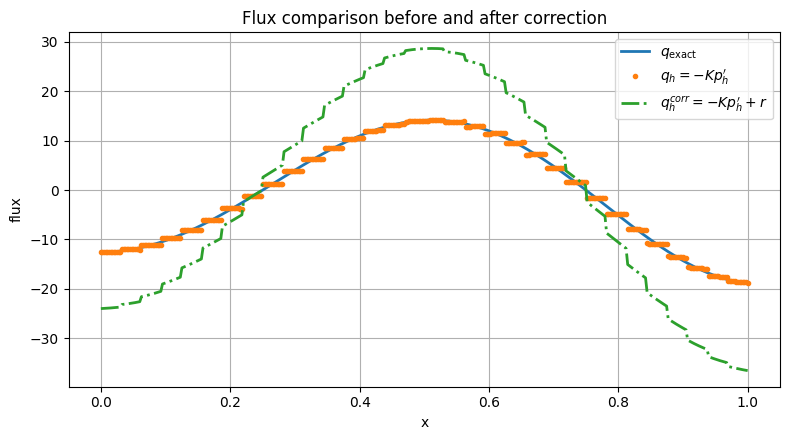

In [5]:
def plot_flux_comparison(domain, ph, model, nplot=400):
    comm = domain.comm
    rank = comm.rank
    tdim = domain.topology.dim

    if tdim != 1:
        raise ValueError("This routine is written for 1D interval meshes only.")

    (
        x_left,
        x_right,
        x_center,
        _dpdx_left,
        _dpdx_center,
        _dpdx_right,
        _d2pdx2_left,
        _d2pdx2_center,
        _d2pdx2_right,
    ) = extract_cell_data_1d(domain, ph)

    if rank != 0:
        return

    V = ph.function_space
    uh = ph.x.array
    basix_el = V.element.basix_element

    x_plot = np.linspace(0.0, 1.0, nplot)
    q_raw_plot = np.zeros_like(x_plot)

    for i, x in enumerate(x_plot):
        cell = np.searchsorted(x_right, x, side="right")
        if cell >= len(x_right):
            cell = len(x_right) - 1

        a = x_left[cell]
        b = x_right[cell]
        h = b - a

        if x >= b and cell == len(x_right) - 1:
            xi = 1.0
        else:
            xi = (x - a) / h

        ref_pt = np.array([[xi]], dtype=np.float64)
        tab = basix_el.tabulate(1, ref_pt)

        dphi_dxi = tab[1, 0, :, 0]

        cell_dofs = V.dofmap.cell_dofs(cell)
        u_cell = uh[cell_dofs]

        dpdx = (dphi_dxi @ u_cell) / h
        q_raw_plot[i] = -(2.0 + x**2) * dpdx

    # Evaluate correction model
    model.eval()
    with torch.no_grad():
        xt = torch.tensor(x_plot.reshape(-1, 1), dtype=torch.float64)
        r_plot = model(xt).cpu().numpy().flatten()

    q_corr_plot = q_raw_plot + r_plot
    q_ex_plot = q_exact_np(x_plot)

    # Plot
    plt.figure(figsize=(8, 4.5))

    plt.plot(x_plot, q_ex_plot, label=r"$q_{\mathrm{exact}}$", linewidth=2)
    plt.plot(x_plot, q_raw_plot, ".", label=r"$q_h = -K p_h'$", linewidth=2)
    plt.plot(x_plot, q_corr_plot, "-.", label=r"$q_h^{corr} = -K p_h' + r$", linewidth=2)

    plt.xlabel("x")
    plt.ylabel("flux")
    plt.title("Flux comparison before and after correction")

    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()
plot_flux_comparison(domain, ph, model)

In [6]:
def print_flux_jumps(domain, ph):
    comm = domain.comm
    rank = comm.rank
    if rank != 0:
        return

    (
        x_left,
        x_right,
        x_center,
        _dpdx_left,
        _dpdx_center,
        _dpdx_right,
        _d2pdx2_left,
        _d2pdx2_center,
        _d2pdx2_right,
    ) = extract_cell_data_1d(domain, ph)

    V = ph.function_space
    uh = ph.x.array
    basix_el = V.element.basix_element

    print("\nInterior flux jumps:")
    print(" i        x_i                 q^-                   q^+                jump=q^+-q^-")
    print("-"*95)

    for i in range(len(x_right) - 1):
        x_int = x_right[i]

        # left trace from cell i at xi=1
        aL = x_left[i]
        bL = x_right[i]
        hL = bL - aL
        refL = np.array([[1.0]], dtype=np.float64)
        tabL = basix_el.tabulate(1, refL)
        dphiL = tabL[1, 0, :, 0]
        dofsL = V.dofmap.cell_dofs(i)
        uL = uh[dofsL]
        dpdxL = (dphiL @ uL) / hL
        qL = -(2.0 + x_int**2) * dpdxL

        # right trace from cell i+1 at xi=0
        aR = x_left[i + 1]
        bR = x_right[i + 1]
        hR = bR - aR
        refR = np.array([[0.0]], dtype=np.float64)
        tabR = basix_el.tabulate(1, refR)
        dphiR = tabR[1, 0, :, 0]
        dofsR = V.dofmap.cell_dofs(i + 1)
        uR = uh[dofsR]
        dpdxR = (dphiR @ uR) / hR
        qR = -(2.0 + x_int**2) * dpdxR

        jump = qR - qL
        print(f"{i:2d}   {x_int: .12e}   {qL: .12e}   {qR: .12e}   {jump: .12e}")

print_flux_jumps(domain,ph)


Interior flux jumps:
 i        x_i                 q^-                   q^+                jump=q^+-q^-
-----------------------------------------------------------------------------------------------
 0    3.125000000000e-02   -1.249106426467e+01   -1.201093178143e+01    4.801324832389e-01
 1    6.250000000000e-02   -1.202851733309e+01   -1.108532811517e+01    9.431892179184e-01
 2    9.375000000000e-02   -1.111233914859e+01   -9.739712664146e+00    1.372626484445e+00
 3    1.250000000000e-01   -9.772857043655e+00   -8.019905355281e+00    1.752951688374e+00
 4    1.562500000000e-01   -8.054875872818e+00   -5.984659178783e+00    2.070216694036e+00
 5    1.875000000000e-01   -6.016415691550e+00   -3.703942904479e+00    2.312472787070e+00
 6    2.187500000000e-01   -3.727048114536e+00   -1.256873088748e+00    2.470175025788e+00
 7    2.500000000000e-01   -1.265863597251e+00    1.270660699522e+00    2.536524296773e+00
 8    2.812500000000e-01    1.280888555531e+00    3.788624734952e+00  